In [ ]:
import os
import sys
import datetime
from pathlib import Path
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
import cartopy.crs as ccrs
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import AutoMinorLocator
sys.path.insert(0, '/home/users/zhiyi/PROJECTS_ANALYSIS')
from zhiyi.plot.Plot_2D import Plot_2D

In [ ]:
BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')

SCRIP_NE60 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc'
FILEBASE_NE60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/'
                 'MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc')
FILEBASE_REGRIDDED = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regridded/'
                      'regrid_to_ne60_MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')

MAP_START = datetime.date(2018, 5, 22)
MAP_END = datetime.date(2018, 6, 14)

PM25_OBS_FILE = '/home/users/zhiyi/PROJECTS_ANALYSIS/extract_data/project_analysis/aurn_observation/PM25/pm2.5_filtered.csv'
O3_OBS_FILE = '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/O3_zs.csv'


def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = template.replace('MM', cur.strftime('%m')).replace('DD', cur.strftime('%d'))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f'Warning: File not found - {f}, skipping.')
        cur += datetime.timedelta(days=1)
    return files


def _selected_date_columns(df):
    date_cols = [
        c for c in df.columns
        if isinstance(c, str)
        and not pd.isna(pd.to_datetime(c, format='%Y-%m-%d', errors='coerce'))
    ]
    dates = pd.to_datetime(date_cols, format='%Y-%m-%d')
    mask = (dates >= pd.to_datetime(MAP_START)) & (dates <= pd.to_datetime(MAP_END))
    return [date_cols[i] for i, ok in enumerate(mask) if ok]


def _obs_map_pm25():
    df = pd.read_csv(PM25_OBS_FILE, skiprows=1)
    selected_cols = _selected_date_columns(df)
    obs_num = df[selected_cols].apply(pd.to_numeric, errors='coerce')
    valobs = obs_num.mean(axis=1).to_numpy()
    color_arr = np.clip(valobs / 24, 0, 1)
    return df['Latitude'].to_numpy(), df['Longitude'].to_numpy() + 360, color_arr


def _obs_map_o3():
    df = pd.read_csv(O3_OBS_FILE)
    selected_cols = _selected_date_columns(df)
    obs_num = df[selected_cols].apply(pd.to_numeric, errors='coerce')
    valobs = (obs_num * 0.498).mean(axis=1).to_numpy()
    color_arr = np.clip(valobs / 65, 0, 1)
    return df['Latitude'].to_numpy(), df['Longitude'].to_numpy() + 360, color_arr


se_files_ne60 = collect_files(FILEBASE_NE60, MAP_START, MAP_END)
se_files_regridded = collect_files(FILEBASE_REGRIDDED, MAP_START, MAP_END)

ds_ne60 = xr.open_mfdataset(se_files_ne60, combine='by_coords')
ds_regridded = xr.open_mfdataset(se_files_regridded, combine='by_coords')

average_data_ne60BB = ds_ne60.sel(time=slice('2018-05-22', '2018-06-14 23:59:59')).mean(dim='time')
average_data_regridded_BB = ds_regridded.sel(time=slice('2018-05-22', '2018-06-14 23:59:59')).mean(dim='time')

pm25_data_ne60BB = average_data_ne60BB['PM25'].isel(lev=-1) * 1e9
pm25_data_regridded_BB = average_data_regridded_BB['PM25'].isel(lev=-1) * 1e9
o3_data_ne60BB = average_data_ne60BB['O3'].isel(lev=-1) * 1e9
o3_data_regridded_BB = average_data_regridded_BB['O3'].isel(lev=-1) * 1e9

pm25_latobs, pm25_lonobs, pm25_color_arr = _obs_map_pm25()
o3_latobs, o3_lonobs, o3_color_arr = _obs_map_o3()

pm25_plot_settings = [
    (SCRIP_NE60, pm25_data_ne60BB, '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
    (SCRIP_NE60, pm25_data_regridded_BB, '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
]

o3_plot_settings = [
    (SCRIP_NE60, o3_data_ne60BB, '', 0, 65, 'O$_{3}$ (ppbv)'),
    (SCRIP_NE60, o3_data_regridded_BB, '', 0, 65, 'O$_{3}$ (ppbv)'),
]

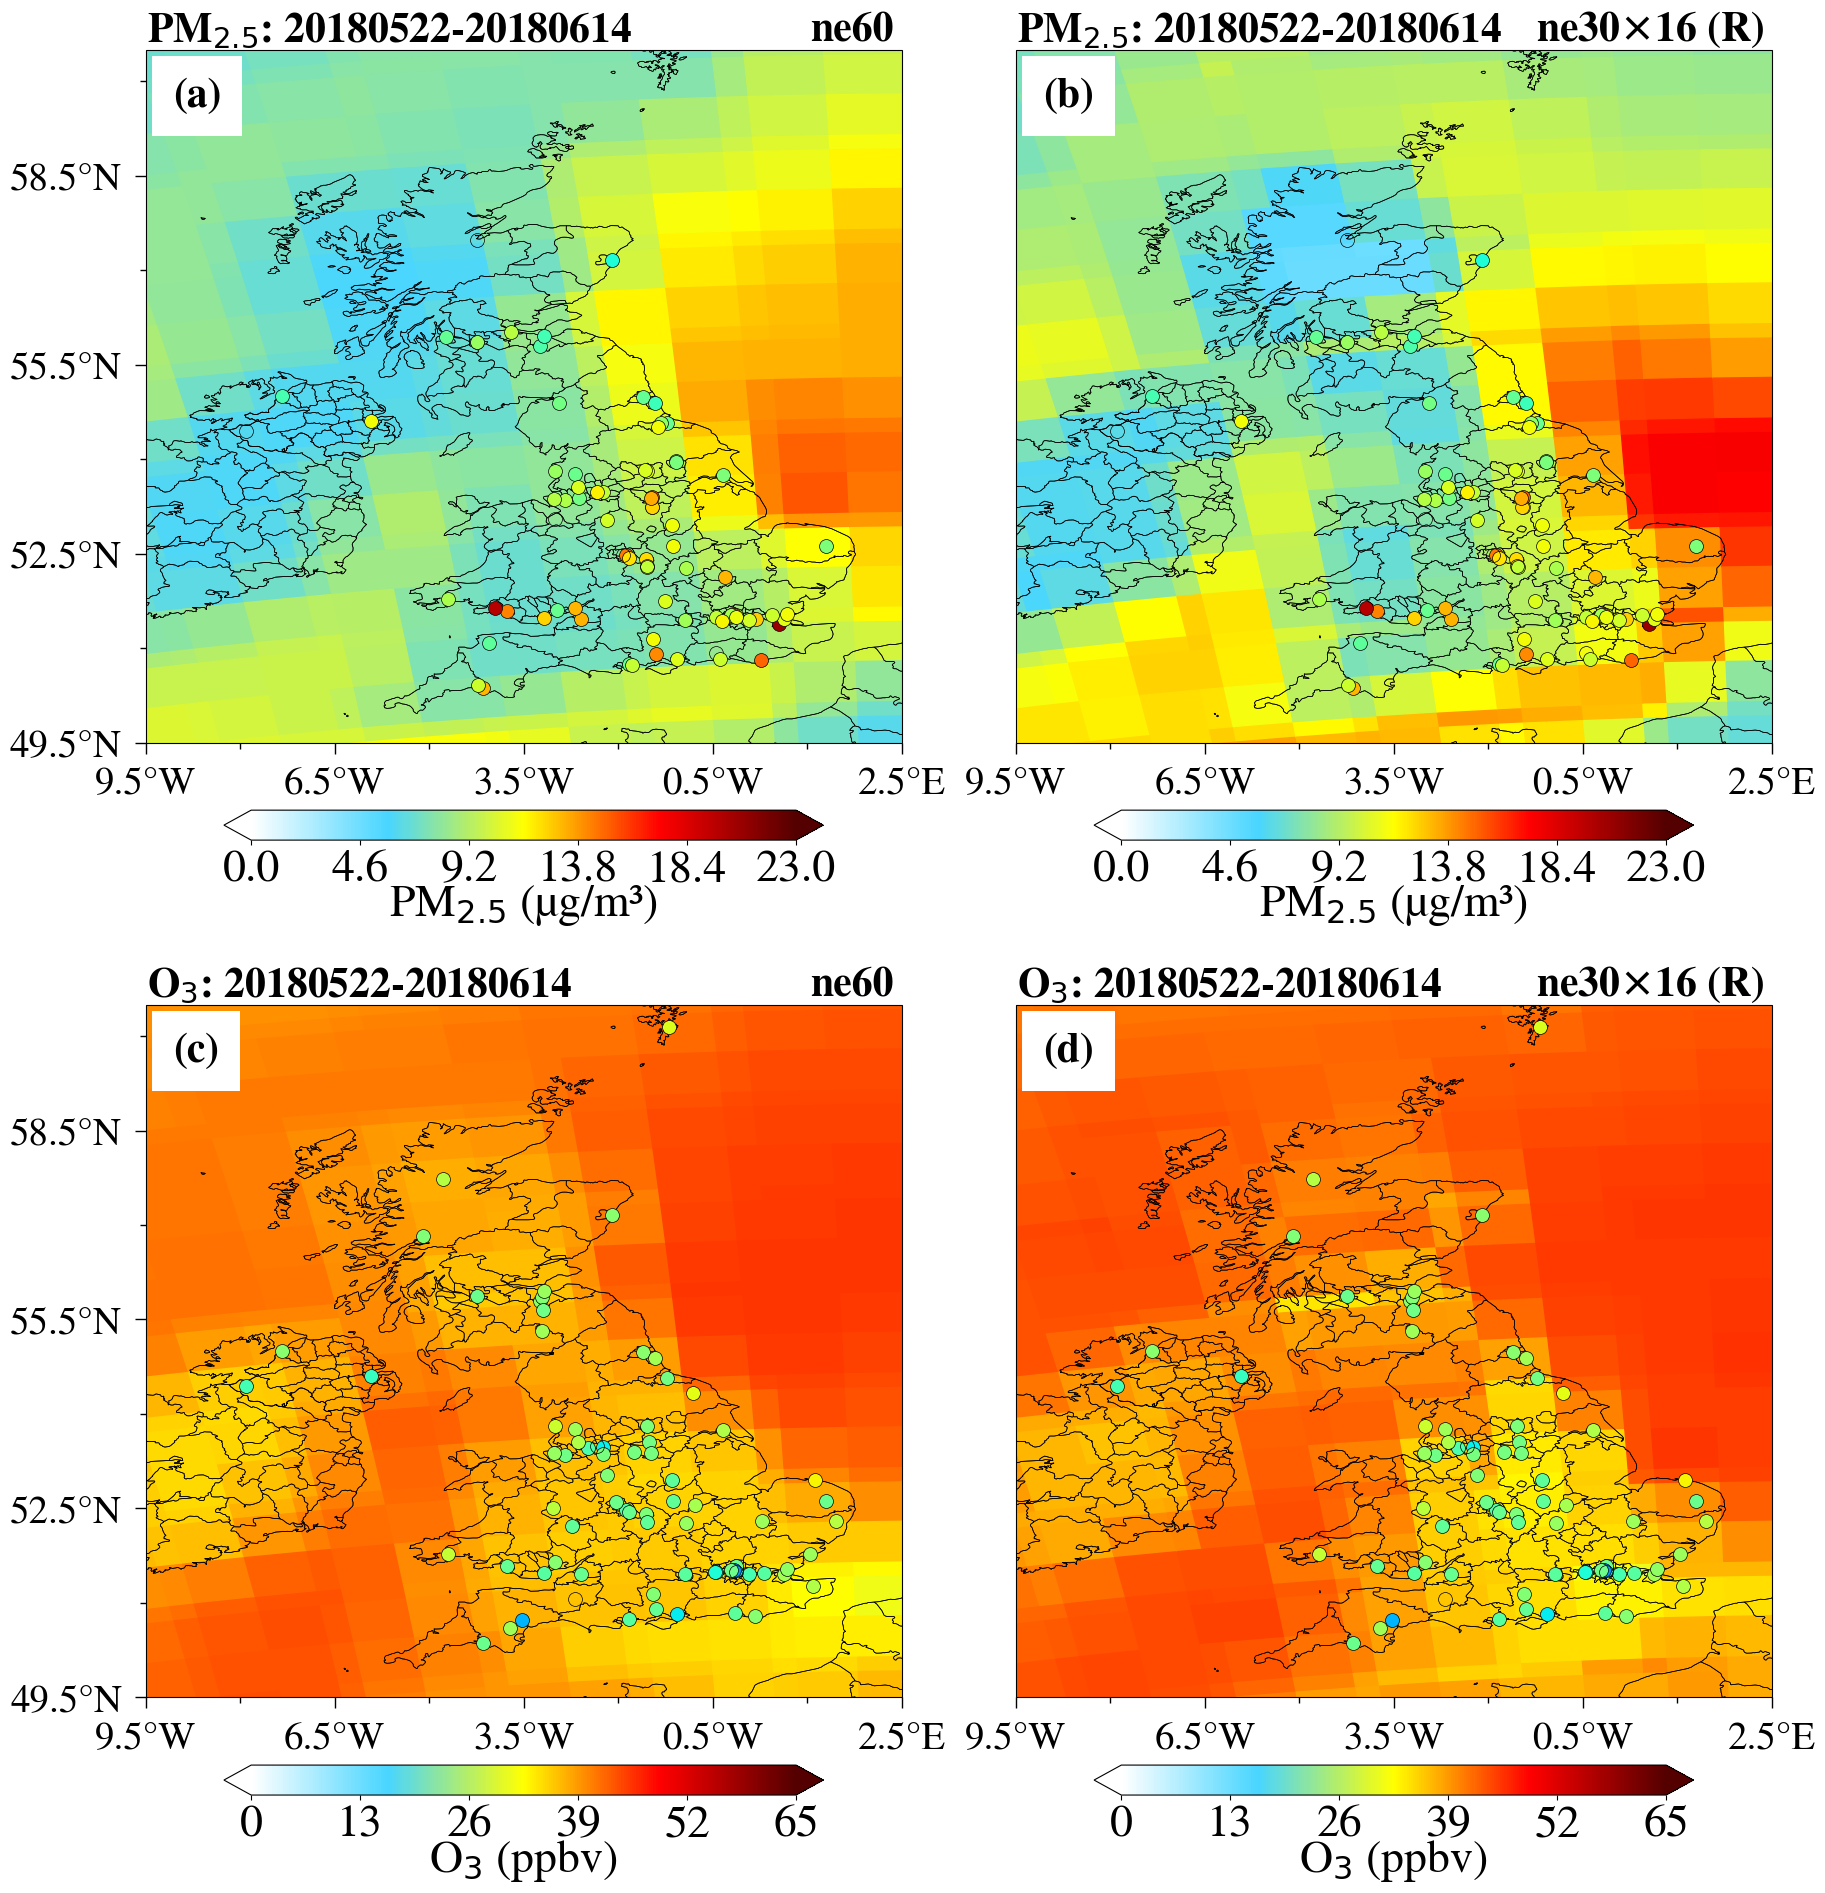

In [10]:

MAP_LON_INTERVAL = 3
MAP_LAT_INTERVAL = 3
MAP_MINOR_TICKS = 2
MAP_X_MAJOR_LABEL_SIZE = 28
MAP_Y_MAJOR_LABEL_SIZE = 28
MAP_MINOR_LABEL_SCALE = 0.8
MAP_MAJOR_TICK_PAD = 9
MAP_MAJOR_TICK_LENGTH = 8
MAP_MINOR_TICK_LENGTH = 4
MAP_TICK_WIDTH = 1
RASTERIZE_MAP_GEOGRAPHY = True

fig = plt.figure(figsize=(25, 20))
map_gs = fig.add_gridspec(
    2, 2,
    left=0.045, right=0.985, bottom=0.055, top=0.955,
    wspace=-0.412, hspace=0.13,
)
map_axes = np.empty((2, 2), dtype=object)
for row in range(2):
    for col in range(2):
        map_axes[row, col] = fig.add_subplot(map_gs[row, col], projection=ccrs.PlateCarree())


def _rasterize_cartopy_features(ax):
    for artist in ax.get_children():
        if type(artist).__module__.startswith('cartopy.mpl.feature_artist'):
            artist.set_rasterized(True)


def _plot_distribution_row(row_axes, plot_settings, latobs, lonobs, color_arr, letters, pollutant_title):
    for i, (scrip, data, title, vmin, vmax, unit) in enumerate(plot_settings):
        ax = row_axes.flat[i]
        p = Plot_2D(
            data,
            scrip_file=scrip, pretty_tick=True,
            lon_range=[-9.5, 2.5], lat_range=[49.5, 60.5],
            lon_interval=MAP_LON_INTERVAL, lat_interval=MAP_LAT_INTERVAL,
            resolution='10m', country=True, state=True, title=title,
            title_bold=True, unit=unit, nticks=6, title_size=20,
            label_size=MAP_Y_MAJOR_LABEL_SIZE, cmax=vmax, cmin=vmin,
            grid_line_lw=0.15, lonlat_line=False,
            shrink=0.54, pad=0.08, unit_offset=[0.05, 0], ax=ax,
        )
        p.im.set_rasterized(True)
        if RASTERIZE_MAP_GEOGRAPHY:
            _rasterize_cartopy_features(ax)

        ax.xaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
        ax.tick_params(
            axis='x', which='major', labelsize=MAP_X_MAJOR_LABEL_SIZE,
            pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )
        ax.tick_params(
            axis='x', which='minor', labelsize=MAP_X_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
            length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )

        if i == 0:
            ax.yaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
            ax.tick_params(
                axis='y', which='major', labelsize=MAP_Y_MAJOR_LABEL_SIZE,
                pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
            ax.tick_params(
                axis='y', which='minor', labelsize=MAP_Y_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
                length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
        if i == 1:
            ax.set_ylabel('', fontsize=18, labelpad=25)
            ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

        cmap = plt.colormaps['jet']
        for lon, lat, color_value in zip(lonobs, latobs, color_arr):
            ax.plot(
                lon, lat, linestyle='none', marker='o', markersize=10,
                c=cmap(color_value), markeredgecolor='black', markeredgewidth=0.5,
                transform=ccrs.PlateCarree(), rasterized=True,
            )

        ax.set_xlabel('', fontsize=18)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=20)
        ax.text(
            0.036, 0.96, letters[i], transform=ax.transAxes,
            fontsize=30, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5', alpha=1),
        )
        ax.text(
            0.002, 1, pollutant_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='left', weight='bold', zorder=10,
        )
        grid_title = r'ne60' if i == 0 else r'ne30$\times$16 (R)'
        ax.text(
            0.99, 1, grid_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='right', weight='bold', zorder=10,
        )


_plot_distribution_row(
    map_axes[0, :], pm25_plot_settings,
    pm25_latobs, pm25_lonobs, pm25_color_arr,
    ['(a)', '(b)'],
    'PM$_{2.5}$: 20180522-20180614',
)

_plot_distribution_row(
    map_axes[1, :], o3_plot_settings,
    o3_latobs, o3_lonobs, o3_color_arr,
    ['(c)', '(d)'],
    'O$_{3}$: 20180522-20180614',
)

CBAR_LENGTH_SCALE = 0.75
CBAR_THICKNESS_SCALE = 1.00
CBAR_X_OFFSET = 0.00
CBAR_Y_OFFSET = 0.00
CBAR_TICK_SIZE = 33
CBAR_UNIT_SIZE = 33

map_cbar_axes = [ax for ax in fig.axes if ax not in map_axes.flat]
for cbar_ax in map_cbar_axes:
    pos = cbar_ax.get_position()
    new_width = pos.width * CBAR_LENGTH_SCALE
    new_height = pos.height * CBAR_THICKNESS_SCALE
    new_x0 = pos.x0 + (pos.width - new_width) / 2 + CBAR_X_OFFSET
    new_y0 = pos.y0 + (pos.height - new_height) / 2 + CBAR_Y_OFFSET
    cbar_ax.set_position([new_x0, new_y0, new_width, new_height])
    cbar_ax.tick_params(labelsize=CBAR_TICK_SIZE)
    for txt in cbar_ax.texts:
        txt.set_position((0.5, -1.4))
        txt.set_ha('center')
        txt.set_va('top')
        txt.set_fontstyle('normal')
        txt.set_fontsize(CBAR_UNIT_SIZE)


In [3]:
figure_data_dir = BASE_DIR / 'figure_data'
figure_data_dir.mkdir(parents=True, exist_ok=True)
figure_s3_path = figure_data_dir / 'FigureS3.nc'


def _surface_values(data_array):
    return np.asarray(data_array.values).reshape(-1)


def _grid_coord(ds, name):
    values = ds[name]
    if 'time' in values.dims:
        values = values.isel(time=0)
    return np.asarray(values.values).reshape(-1)


FigureS3 = xr.Dataset(
    data_vars={
        'pm25_map_ne60': (('ncol_ne60',), _surface_values(pm25_data_ne60BB)),
        'pm25_map_regridded': (('ncol_regridded',), _surface_values(pm25_data_regridded_BB)),
        'o3_map_ne60': (('ncol_ne60',), _surface_values(o3_data_ne60BB)),
        'o3_map_regridded': (('ncol_regridded',), _surface_values(o3_data_regridded_BB)),
        'lon_ne60': (('ncol_ne60',), _grid_coord(ds_ne60, 'lon')),
        'lat_ne60': (('ncol_ne60',), _grid_coord(ds_ne60, 'lat')),
        'lon_regridded': (('ncol_regridded',), _grid_coord(ds_regridded, 'lon')),
        'lat_regridded': (('ncol_regridded',), _grid_coord(ds_regridded, 'lat')),
        'pm25_obs_map_lat': (('pm25_obs',), np.asarray(pm25_latobs, dtype=float)),
        'pm25_obs_map_lon': (('pm25_obs',), np.asarray(pm25_lonobs, dtype=float)),
        'pm25_obs_map_color': (('pm25_obs',), np.asarray(pm25_color_arr, dtype=float)),
        'o3_obs_map_lat': (('o3_obs',), np.asarray(o3_latobs, dtype=float)),
        'o3_obs_map_lon': (('o3_obs',), np.asarray(o3_lonobs, dtype=float)),
        'o3_obs_map_color': (('o3_obs',), np.asarray(o3_color_arr, dtype=float)),
    },
)

FigureS3.to_netcdf(figure_s3_path)
FigureS3.close()
print(figure_s3_path)


/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS3.nc


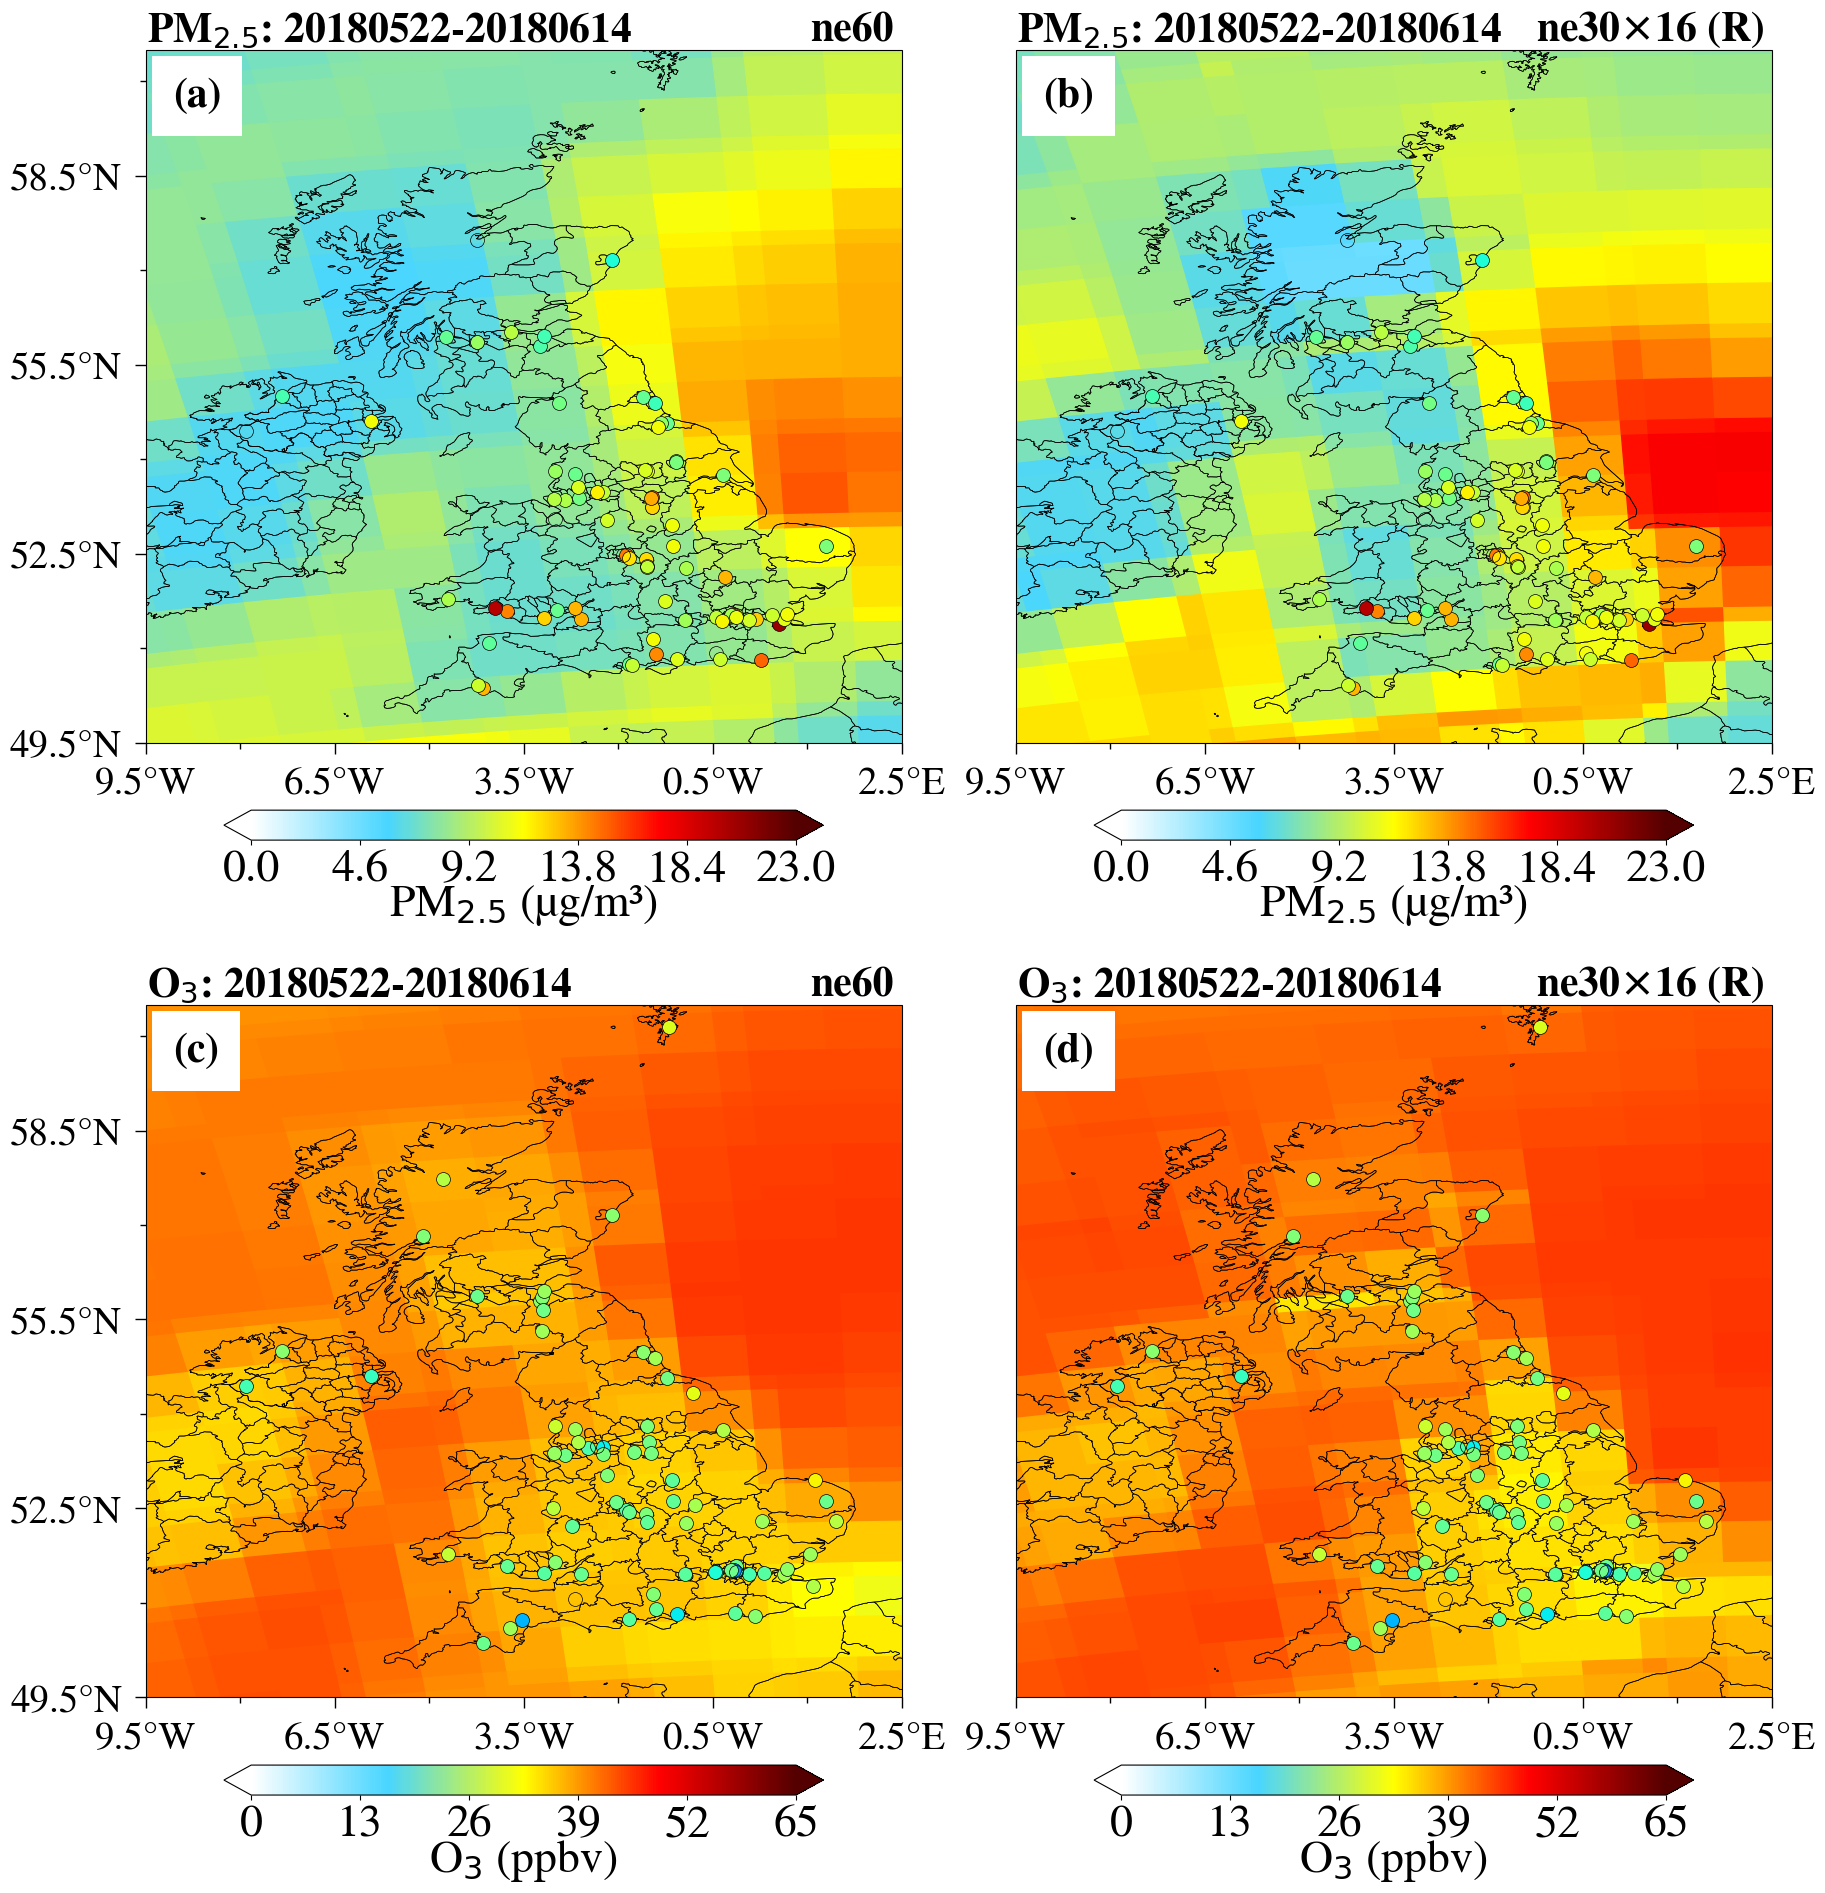

In [9]:
import os
import sys
from pathlib import Path

os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.ticker import AutoMinorLocator

sys.path.insert(0, '/home/users/zhiyi/PROJECTS_ANALYSIS')
from zhiyi.plot.Plot_2D import Plot_2D

BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')
SCRIP_NE60 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc'
figure_s3_path = BASE_DIR / 'figure_data' / 'FigureS3.nc'
FigureS3_saved = xr.open_dataset(figure_s3_path)

saved_pm25_plot_settings = [
    (SCRIP_NE60, FigureS3_saved['pm25_map_ne60'], '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
    (SCRIP_NE60, FigureS3_saved['pm25_map_regridded'], '', 0, 23, 'PM$_{2.5}$ (µg/m³)'),
]

saved_o3_plot_settings = [
    (SCRIP_NE60, FigureS3_saved['o3_map_ne60'], '', 0, 65, 'O$_{3}$ (ppbv)'),
    (SCRIP_NE60, FigureS3_saved['o3_map_regridded'], '', 0, 65, 'O$_{3}$ (ppbv)'),
]

MAP_LON_INTERVAL = 3
MAP_LAT_INTERVAL = 3
MAP_MINOR_TICKS = 2
MAP_X_MAJOR_LABEL_SIZE = 28
MAP_Y_MAJOR_LABEL_SIZE = 28
MAP_MINOR_LABEL_SCALE = 0.8
MAP_MAJOR_TICK_PAD = 9
MAP_MAJOR_TICK_LENGTH = 8
MAP_MINOR_TICK_LENGTH = 4
MAP_TICK_WIDTH = 1
RASTERIZE_MAP_GEOGRAPHY = True

fig = plt.figure(figsize=(25, 20))
map_gs = fig.add_gridspec(
    2, 2,
    left=0.045, right=0.985, bottom=0.055, top=0.955,
    wspace=-0.412, hspace=0.13,
)
map_axes_saved = np.empty((2, 2), dtype=object)
for row in range(2):
    for col in range(2):
        map_axes_saved[row, col] = fig.add_subplot(map_gs[row, col], projection=ccrs.PlateCarree())


def _rasterize_cartopy_features_saved(ax):
    for artist in ax.get_children():
        if type(artist).__module__.startswith('cartopy.mpl.feature_artist'):
            artist.set_rasterized(True)


def _plot_distribution_row_from_saved(row_axes, plot_settings, latobs, lonobs, color_arr, letters, pollutant_title):
    for i, (scrip, data, title, vmin, vmax, unit) in enumerate(plot_settings):
        ax = row_axes.flat[i]
        p = Plot_2D(
            data,
            scrip_file=scrip, pretty_tick=True,
            lon_range=[-9.5, 2.5], lat_range=[49.5, 60.5],
            lon_interval=MAP_LON_INTERVAL, lat_interval=MAP_LAT_INTERVAL,
            resolution='10m', country=True, state=True, title=title,
            title_bold=True, unit=unit, nticks=6, title_size=20,
            label_size=MAP_Y_MAJOR_LABEL_SIZE, cmax=vmax, cmin=vmin,
            grid_line_lw=0.15, lonlat_line=False,
            shrink=0.54, pad=0.08, unit_offset=[0.05, 0], ax=ax,
        )
        p.im.set_rasterized(True)
        if RASTERIZE_MAP_GEOGRAPHY:
            _rasterize_cartopy_features_saved(ax)

        ax.xaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
        ax.tick_params(
            axis='x', which='major', labelsize=MAP_X_MAJOR_LABEL_SIZE,
            pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )
        ax.tick_params(
            axis='x', which='minor', labelsize=MAP_X_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
            length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
        )

        if i == 0:
            ax.yaxis.set_minor_locator(AutoMinorLocator(MAP_MINOR_TICKS))
            ax.tick_params(
                axis='y', which='major', labelsize=MAP_Y_MAJOR_LABEL_SIZE,
                pad=MAP_MAJOR_TICK_PAD, length=MAP_MAJOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
            ax.tick_params(
                axis='y', which='minor', labelsize=MAP_Y_MAJOR_LABEL_SIZE * MAP_MINOR_LABEL_SCALE,
                length=MAP_MINOR_TICK_LENGTH, width=MAP_TICK_WIDTH,
            )
        if i == 1:
            ax.set_ylabel('', fontsize=18, labelpad=25)
            ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

        cmap = plt.colormaps['jet']
        for lon, lat, color_value in zip(lonobs, latobs, color_arr):
            ax.plot(
                lon, lat, linestyle='none', marker='o', markersize=10,
                c=cmap(color_value), markeredgecolor='black', markeredgewidth=0.5,
                transform=ccrs.PlateCarree(), rasterized=True,
            )

        ax.set_xlabel('', fontsize=18)
        ax.xaxis.set_tick_params(labelbottom=True)
        ax.set_title(ax.get_title(), fontsize=30, weight='bold', pad=20)
        ax.text(
            0.036, 0.96, letters[i], transform=ax.transAxes,
            fontsize=30, va='top', ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.5', alpha=1),
        )
        ax.text(
            0.002, 1, pollutant_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='left', weight='bold', zorder=10,
        )
        grid_title = r'ne60' if i == 0 else r'ne30$\times$16 (R)'
        ax.text(
            0.99, 1, grid_title, transform=ax.transAxes,
            fontsize=30, va='bottom', ha='right', weight='bold', zorder=10,
        )


_plot_distribution_row_from_saved(
    map_axes_saved[0, :], saved_pm25_plot_settings,
    FigureS3_saved['pm25_obs_map_lat'].values,
    FigureS3_saved['pm25_obs_map_lon'].values,
    FigureS3_saved['pm25_obs_map_color'].values,
    ['(a)', '(b)'],
    'PM$_{2.5}$: 20180522-20180614',
)

_plot_distribution_row_from_saved(
    map_axes_saved[1, :], saved_o3_plot_settings,
    FigureS3_saved['o3_obs_map_lat'].values,
    FigureS3_saved['o3_obs_map_lon'].values,
    FigureS3_saved['o3_obs_map_color'].values,
    ['(c)', '(d)'],
    'O$_{3}$: 20180522-20180614',
)

CBAR_LENGTH_SCALE = 0.75
CBAR_THICKNESS_SCALE = 1.00
CBAR_X_OFFSET = 0.00
CBAR_Y_OFFSET = 0.00
CBAR_TICK_SIZE = 33
CBAR_UNIT_SIZE = 33

saved_cbar_axes = [ax for ax in fig.axes if ax not in map_axes_saved.flat]
for cbar_ax in saved_cbar_axes:
    pos = cbar_ax.get_position()
    new_width = pos.width * CBAR_LENGTH_SCALE
    new_height = pos.height * CBAR_THICKNESS_SCALE
    new_x0 = pos.x0 + (pos.width - new_width) / 2 + CBAR_X_OFFSET
    new_y0 = pos.y0 + (pos.height - new_height) / 2 + CBAR_Y_OFFSET
    cbar_ax.set_position([new_x0, new_y0, new_width, new_height])
    cbar_ax.tick_params(labelsize=CBAR_TICK_SIZE)
    for txt in cbar_ax.texts:
        txt.set_position((0.5, -1.4))
        txt.set_ha('center')
        txt.set_va('top')
        txt.set_fontstyle('normal')
        txt.set_fontsize(CBAR_UNIT_SIZE)


FIGURES_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / 'FigureS3.png'
pdf_path = FIGURES_DIR / 'FigureS3.pdf'

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches='tight', facecolor='white')

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis('off')
pdf_fig.savefig(pdf_path, format='pdf', dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor='white')
plt.close(pdf_fig)
